In [25]:
import networkx as nx
import numpy as np
#from bngenerator import *
from bngenerator import *
from matplotlib import pyplot as plt
from pgmpy.readwrite.XMLBeliefNetwork import XBNReader, XBNWriter
from pgmpy.readwrite import BIFWriter, BIFReader
import os

#writer = BIFWriter(model)
#writer.write_bif("model.bif")
#my_dag = BIFReader("model.bif").get_model()

In [2]:
gen = BayesianNetworkGenerator(
        n_nodes=60,
        max_induced_width=12,
        max_degree=20,
        n_iterations=1000
    )

In [3]:
dag = gen.generate().dag

In [ ]:
INDUCED_WIDTH = [2, 6, 12] #(SPARSE, MEDIUM, DENSE)
NUM_NODES = [10, 20, 30, 40, 50, 80, 100, 200, 500, 1000] # H_size = num_nodes * 0.25, following Chen et al.

def _density_label(induced_width: int) -> str:
    if induced_width <= 2:
        return "sparse"
    elif induced_width <= 6:
        return "medium"
    else:
        return "dense"

In [28]:
from dataclasses import dataclass
@dataclass(frozen=True)
class CPDParam:
    """
    A single (alpha, beta) configuration for CPD sampling.
 
    alpha, beta : Beta distribution parameters.
    label       : Short identifier used in filenames.
    description : Human-readable explanation of the regime.
    """
    alpha: float
    beta: float
    label: str
    description: str
 
 
# Nine configurations covering the rigidity × bias space.
CPD_PARAMS: List[CPDParam] = [
    # ── Symmetric (unbiased, mean(p) = 0.5) ──────────────────
    CPDParam(0.2,  0.2,  "rigid_extreme",       "Bimodal: CPDs overwhelmingly near 0 or 1"),
    CPDParam(0.5,  0.5,  "rigid_moderate",      "U-shaped: CPDs skewed toward extremes"),
    CPDParam(1.0,  1.0,  "uniform",             "Uniform: all CPD values equally likely"),
    CPDParam(3.0,  3.0,  "uncertain_moderate",      "Bell-shaped: CPDs concentrated near 0.5"),
    CPDParam(10.0, 10.0, "uncertain_strong",        "Tightly concentrated near 0.5"),

    # ── Asymmetric: biased toward 0 ───────────────────────────
    # Beta(0.5, 2.0): spread across [0,1] but pulled toward 0
    CPDParam(0.5,  2.0,  "spread_bias_low",     "Spread + biased low: mean(p) ≈ 0.20, some variance"),
    # Beta(1.0, 5.0): concentrated near 0 — deterministic in the low direction
    CPDParam(1.0,  5.0,  "concentrated_bias_low","Concentrated near 0: mean(p) ≈ 0.17, low variance"),

    # ── Asymmetric: biased toward 1 ───────────────────────────
    # Beta(2.0, 0.5): spread across [0,1] but pulled toward 1
    CPDParam(2.0,  0.5,  "spread_bias_high",    "Spread + biased high: mean(p) ≈ 0.80, some variance"),
    # Beta(5.0, 1.0): concentrated near 1 — deterministic in the high direction
    CPDParam(5.0,  1.0,  "concentrated_bias_high","Concentrated near 1: mean(p) ≈ 0.83, low variance"),
]

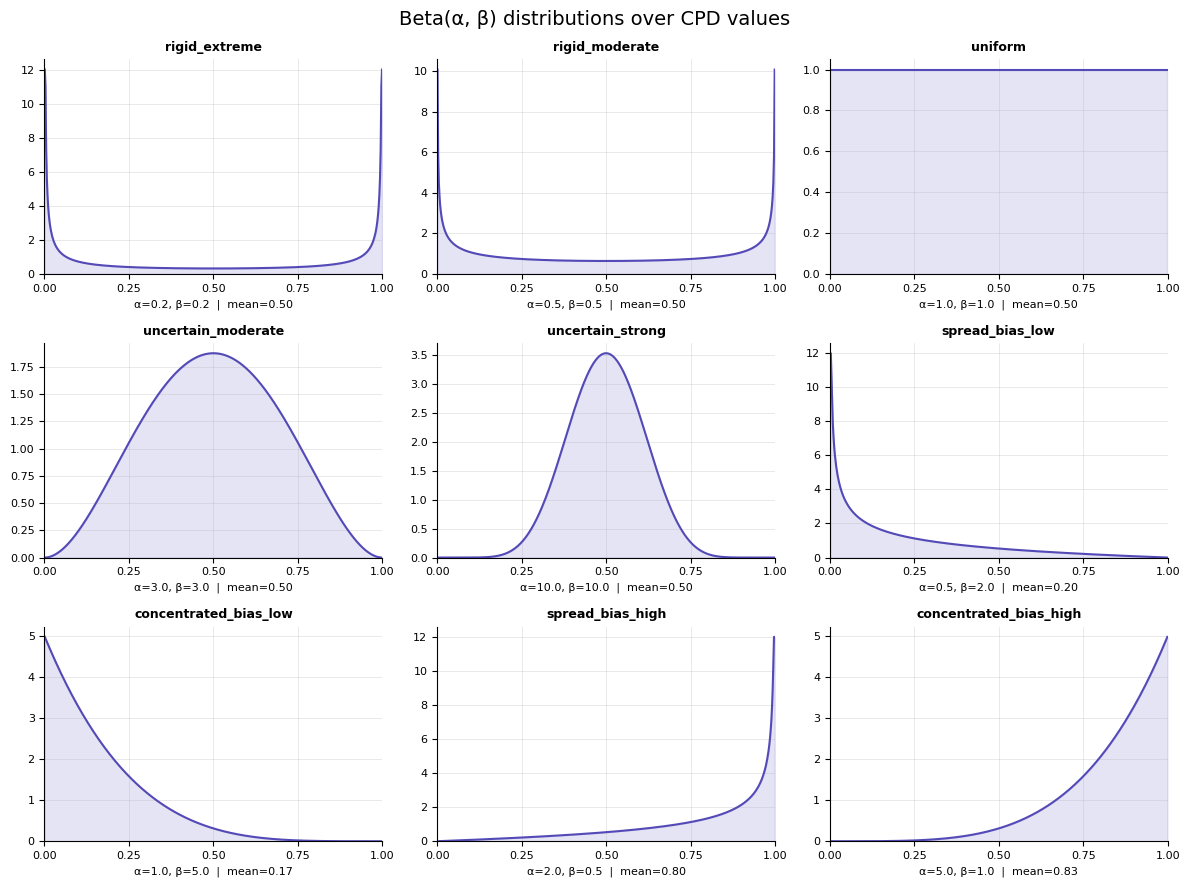

In [29]:
from scipy.stats import beta as beta_dist

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
fig.suptitle("Beta(α, β) distributions over CPD values", fontsize=14)

for ax, param in zip(axes.flat, CPD_PARAMS):
    x = np.linspace(0.001, 0.999, 500)
    y = beta_dist.pdf(x, param.alpha, param.beta)
    y = np.clip(y, 0, 12)  # cap extreme density near boundaries

    ax.plot(x, y, color="#534AB7", linewidth=1.5)
    ax.fill_between(x, y, alpha=0.15, color="#534AB7")
    ax.set_title(param.label, fontsize=9, fontweight="bold")
    ax.set_xlabel(f"α={param.alpha}, β={param.beta}  |  mean={param.alpha/(param.alpha+param.beta):.2f}", fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.tick_params(labelsize=8)
    ax.grid(True, linewidth=0.4, alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
from scipy.integrate import quad

def expected_cpd_entropy(alpha, beta):
    """E[H(Bernoulli(p))] where p ~ Beta(alpha, beta). Always in [0, 1] bits."""
    def integrand(p):
        if p <= 0 or p >= 1:
            return 0.0
        bernoulli_h = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
        beta_density = beta_dist.pdf(p, alpha, beta)
        return bernoulli_h * beta_density

    result, _ = quad(integrand, 0, 1, limit=200)
    return result

for param in CPD_PARAMS:
    mean = param.alpha / (param.alpha + param.beta)
    var  = (param.alpha * param.beta) / (
           (param.alpha + param.beta) ** 2 * (param.alpha + param.beta + 1))
    diff_entropy     = beta_dist.entropy(param.alpha, param.beta)
    expected_entropy = expected_cpd_entropy(param.alpha, param.beta)
    print(f"{param.label:<26}  mean={mean:.3f}  var={var:.5f}  "
          f"diff_H={diff_entropy:+.3f}  E[H_cpd]={expected_entropy:.3f}")

/home/joao/anaconda3/envs/bn-medical/lib/python3.8/site-packages/scipy/stats/_distn_infrastructure.py:2655: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  h = integrate.quad(integ, _a, _b)[0]


rigid_extreme               mean=0.500  var=0.17857  diff_H=-2.113  E[H_cpd]=0.328
rigid_moderate              mean=0.500  var=0.12500  diff_H=-0.242  E[H_cpd]=0.557
uniform                     mean=0.500  var=0.08333  diff_H=+0.000  E[H_cpd]=0.721
uncertain_moderate          mean=0.500  var=0.03571  diff_H=-0.268  E[H_cpd]=0.890
uncertain_strong            mean=0.500  var=0.01190  diff_H=-0.798  E[H_cpd]=0.965
spread_bias_low             mean=0.200  var=0.04571  diff_H=-0.765  E[H_cpd]=0.516
concentrated_bias_low       mean=0.167  var=0.01984  diff_H=-0.809  E[H_cpd]=0.549
spread_bias_high            mean=0.800  var=0.04571  diff_H=-0.765  E[H_cpd]=0.516
concentrated_bias_high      mean=0.833  var=0.01984  diff_H=-0.809  E[H_cpd]=0.549


In [31]:
len(CPD_PARAMS) * len(INDUCED_WIDTH) * len(NUM_NODES)

297

In [32]:
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD

def generate_controlled_binary_bn(
    num_nodes: int,
    induced_width: int,
    cpd_alpha: float,
    cpd_beta: float,
) -> BayesianNetwork:

    # ── 1. Generate DAG structure ─────────────────────────────
    generator = BayesianNetworkGenerator(
        n_nodes=num_nodes,
        max_induced_width=induced_width,
        max_degree=20,
        n_iterations=2_000,
    )
    dag = generator.generate().dag
 
    # ── 2. Build pgmpy BayesianNetwork ───────────────────────
    edges = [(f"X{u}", f"X{v}") for u, v in dag.edges()]
    bn = BayesianNetwork(edges)
 
    # Ensure isolated nodes are present
    for i in range(num_nodes):
        node = f"X{i}"
        if node not in bn.nodes():
            bn.add_node(node)
 
    # ── 3. Attach CPDs ────────────────────────────────────────
    for node in bn.nodes():
        parents = list(bn.get_parents(node))
        num_parents = len(parents)
        num_parent_configs = 2 ** num_parents
 
        # One probability draw per parent configuration.
        # p_true[k] = P(node=True | parent config k)
        p_true = np.random.beta(cpd_alpha, cpd_beta, size=num_parent_configs)
        p_false = 1.0 - p_true
 
        cpd = TabularCPD(
            variable=node,
            variable_card=2,
            values=[p_false.tolist(), p_true.tolist()],
            evidence=parents if num_parents > 0 else None,
            evidence_card=[2] * num_parents if num_parents > 0 else None,
            state_names={node: [0, 1], **{p: [0, 1] for p in parents}},
        )
        bn.add_cpds(cpd)
 
    assert bn.check_model(), "pgmpy model validation failed."
    return bn


In [38]:
def generate_and_save_bns(
    output_dir: str = "generated_bif_files",
    induced_widths: List[int] = INDUCED_WIDTH,
    num_nodes_list: List[int] = NUM_NODES,
    cpd_params: List[CPDParam] = CPD_PARAMS,
) -> None:
    """
    Iterate over all factor combinations, generate BNs, and save as BIF files.
 
    File naming convention
    ----------------------
    bn_n{N}_w{W}-{density}_a{A}-b{B}-{cpd_label}.bif
 
    Example:
        bn_n20_w2-sparse_a0.1-b0.1-rigid_extreme.bif
        bn_n50_w6-medium_a1.0-b5.0-fuzzy_bias_low.bif
    """
    os.makedirs(output_dir, exist_ok=True)
 
    total = len(num_nodes_list) * len(induced_widths) * len(cpd_params)
    done = 0
 
    for n in num_nodes_list:
        for w in induced_widths:
            for cp in cpd_params:
                done += 1
                tag = (
                    f"n={n:>3d} | w={w:>2d} ({_density_label(w):<6}) | "
                    f"α={cp.alpha:<5.1f} β={cp.beta:<5.1f} ({cp.label})"
                )
                print(f"[{done:>3}/{total}] Generating {tag} ...", end=" ", flush=True)
 
                try:
                    bn = generate_controlled_binary_bn(
                        num_nodes=n,
                        induced_width=w,
                        cpd_alpha=cp.alpha,
                        cpd_beta=cp.beta,
                    )
 
                    filename = (
                        f"bn_n{n}_w{w}_{cp.label}.bif"
                    )
                    filepath = os.path.join(output_dir, filename)
 
                    writer = BIFWriter(bn)
                    writer.write_bif(filepath)
                    print(f"-> saved {filename}")
 
                except Exception as exc:
                    print(f"-> [ERROR] {exc}")

In [40]:
generate_and_save_bns()

[  1/297] Generating n= 10 | w= 2 (sparse) | α=0.2   β=0.2   (rigid_extreme) ... -> saved bn_n10_w2_rigid_extreme.bif
[  2/297] Generating n= 10 | w= 2 (sparse) | α=0.5   β=0.5   (rigid_moderate) ... -> saved bn_n10_w2_rigid_moderate.bif
[  3/297] Generating n= 10 | w= 2 (sparse) | α=1.0   β=1.0   (uniform) ... -> saved bn_n10_w2_uniform.bif
[  4/297] Generating n= 10 | w= 2 (sparse) | α=3.0   β=3.0   (uncertain_moderate) ... -> saved bn_n10_w2_uncertain_moderate.bif
[  5/297] Generating n= 10 | w= 2 (sparse) | α=10.0  β=10.0  (uncertain_strong) ... -> saved bn_n10_w2_uncertain_strong.bif
[  6/297] Generating n= 10 | w= 2 (sparse) | α=0.5   β=2.0   (spread_bias_low) ... -> saved bn_n10_w2_spread_bias_low.bif
[  7/297] Generating n= 10 | w= 2 (sparse) | α=1.0   β=5.0   (concentrated_bias_low) ... -> saved bn_n10_w2_concentrated_bias_low.bif
[  8/297] Generating n= 10 | w= 2 (sparse) | α=2.0   β=0.5   (spread_bias_high) ... -> saved bn_n10_w2_spread_bias_high.bif
[  9/297] Generating n= 

KeyboardInterrupt: 